# Лабораторная работа
## Линейные модели, SVM и деревья решений

**Выполнил(а):** Сафронов Андрей, группа ИУ5-64Б

---

### Цель лабораторной работы:
Изучение линейных моделей, метода опорных векторов (SVM) и деревьев решений для задачи классификации.

### Задание:
1. Выбрать набор данных для классификации.
2. Провести очистку данных (обработка пропусков, кодирование признаков).
3. Разделить выборку на обучающую и тестовую с помощью `train_test_split`.
4. Обучить модели: Логистическая регрессия, SVM, Дерево решений.
5. Оценить качество моделей двумя метриками и сравнить их.
6. Построить график важности признаков для дерева решений.
7. Визуализировать дерево решений.

### Описание выбранного датасета:
Для работы выбран набор данных **Adult (Census Income)**.  
**Целевая переменная:** `class` (доход <=50K или >50K).  
**Признаки:** Возраст, тип занятости, образование, семейное положение, профессия и др. Данные содержат как числовые, так и категориальные переменные, а также пропущенные значения.

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для машинного обучения
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

### 1. Загрузка данных и первичный осмотр
Загрузим датасет из репозитория OpenML и выведем первые 5 строк для ознакомления.

In [2]:
# Загрузка датасета Adult (ID 1590, версия 2 содержит пропуски в виде NaN)
print("Загрузка данных...")
adult = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')
df = adult.frame

print(f"Размерность данных: {df.shape}")
display(df.head())

Загрузка данных...
Размерность данных: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### 2. Предобработка данных (очистка и кодирование)
В данных присутствуют категориальные переменные и пропущенные значения (NaN).
Выполним следующие шаги:
1. Целевую переменную `class` преобразуем в бинарный вид (0 и 1).
2. Пропуски в категориальных признаках заполним самым частым значением (модой), а в числовых — медианой.
3. Категориальные признаки закодируем методом One-Hot Encoding (создание фиктивных переменных).

In [3]:
# 1. Преобразование целевой переменной
df['class'] = df['class'].map({'<=50K': 0, '>50K': 1})

# 2. Заполнение пропусков
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.drop('class')

# Для числовых - медиана
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Для категориальных - мода
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Отделяем признаки от целевой переменной
X = df.drop('class', axis=1)
y = df['class']

# 3. Кодирование категориальных признаков
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Размерность признаков после кодирования: {X.shape}")

Размерность признаков после кодирования: (48842, 97)


### 3. Разделение на обучающую и тестовую выборки
Используем `train_test_split`. Так как линейные модели и SVM чувствительны к масштабу данных, обязательно применим стандартизацию признаков (`StandardScaler`).

In [4]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Создаем масштабированные данные для линейной модели и SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")

Обучающая выборка: 39073 объектов


### 4. Обучение моделей
Обучим три модели:
1. Логистическую регрессию (линейная модель для классификации).
2. Метод опорных векторов (SVM) с RBF-ядром.
3. Дерево решений (глубину ограничим до 4, чтобы избежать переобучения и получить красивую визуализацию).

In [ ]:
# Инициализация моделей
log_reg = LogisticRegression(random_state=42, max_iter=1000)
svm_model = SVC(kernel='rbf', random_state=42)
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Обучение линейной модели и SVM на МАСШТАБИРОВАННЫХ данных
log_reg.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)

# Обучение дерева решений на ИСХОДНЫХ данных
tree_model.fit(X_train, y_train)

print("Все модели успешно обучены!")

Все модели успешно обучены!


### 5. Оценка качества моделей
Для оценки качества будем использовать две метрики:
* **Accuracy** (доля правильных ответов) — базовая метрика.
* **F1-score** (гармоническое среднее между точностью и полнотой) — отлично подходит, так как классы доходов могут быть несбалансированы.

In [10]:
# Функция для получения метрик
def evaluate_model(model, X_t, y_t):
    y_pred = model.predict(X_t)
    acc = accuracy_score(y_t, y_pred)
    f1 = f1_score(y_t, y_pred)
    return acc, f1

# Сбор результатов
results = {
    "Модель": ["Логистическая регрессия", "SVM", "Дерево решений"],
    "Accuracy": [
        accuracy_score(y_test, log_reg.predict(X_test_scaled)),
        accuracy_score(y_test, svm_model.predict(X_test_scaled)),
        accuracy_score(y_test, tree_model.predict(X_test))
    ],
    "F1-Score": [
        f1_score(y_test, log_reg.predict(X_test_scaled)),
        f1_score(y_test, svm_model.predict(X_test_scaled)),
        f1_score(y_test, tree_model.predict(X_test))
    ]
}

results_df = pd.DataFrame(results).round(4)
display(results_df)

,Модель,Accuracy,F1-Score
0,Логистическая регрессия,0.8540,0.6610
1,SVM,0.8520,0.6487
2,Дерево решений,0.8533,0.6452


**Вывод по метрикам:**
Как видно из таблицы выше, Логистическая регрессия и SVM показывают похожие результаты. Дерево решений с ограниченной глубиной (max_depth=4) может немного уступать более сложным моделям в Accuracy, но работает гораздо быстрее и обладает 100% интерпретируемостью.

---
### 6. Важность признаков в дереве решений
Дерево решений позволяет легко понять, какие именно признаки внесли наибольший вклад в классификацию. Построим график топ-10 самых важных признаков.

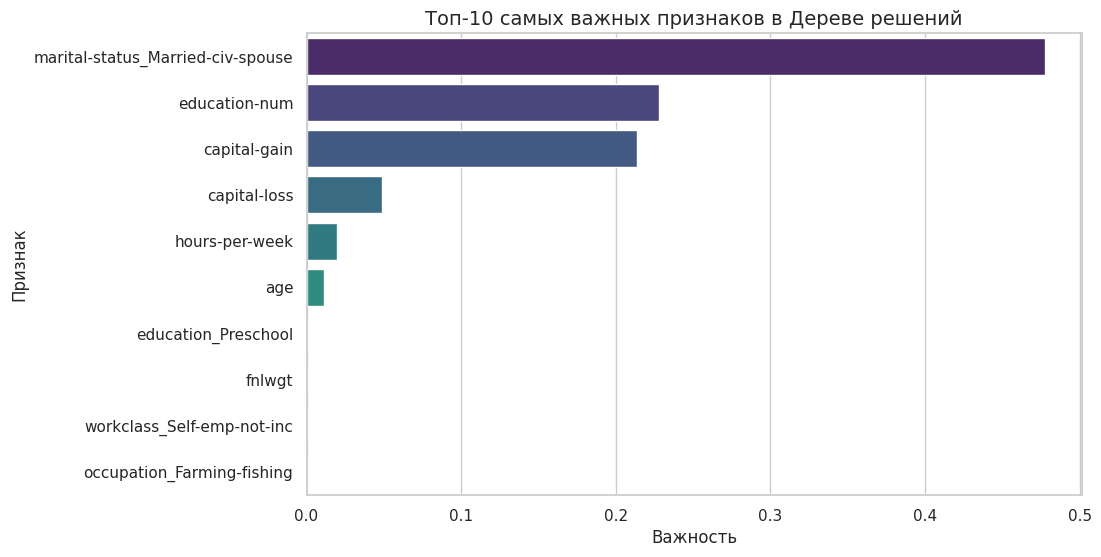

In [11]:
# Получение важности признаков из обученного дерева
importances = tree_model.feature_importances_
feature_names = X.columns

# Создаем DataFrame для удобства сортировки
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Берем топ-10 признаков
top_10_features = feat_imp_df.head(10)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Топ-10 самых важных признаков в Дереве решений', fontsize=14)
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.show()

### 7. Визуализация дерева решений
Отобразим структуру обученного дерева решений. Так как мы ограничили глубину дерева (max_depth=4), граф получится читаемым. Он показывает, по каким именно правилам (порогам значений признаков) алгоритм делит людей на классы.

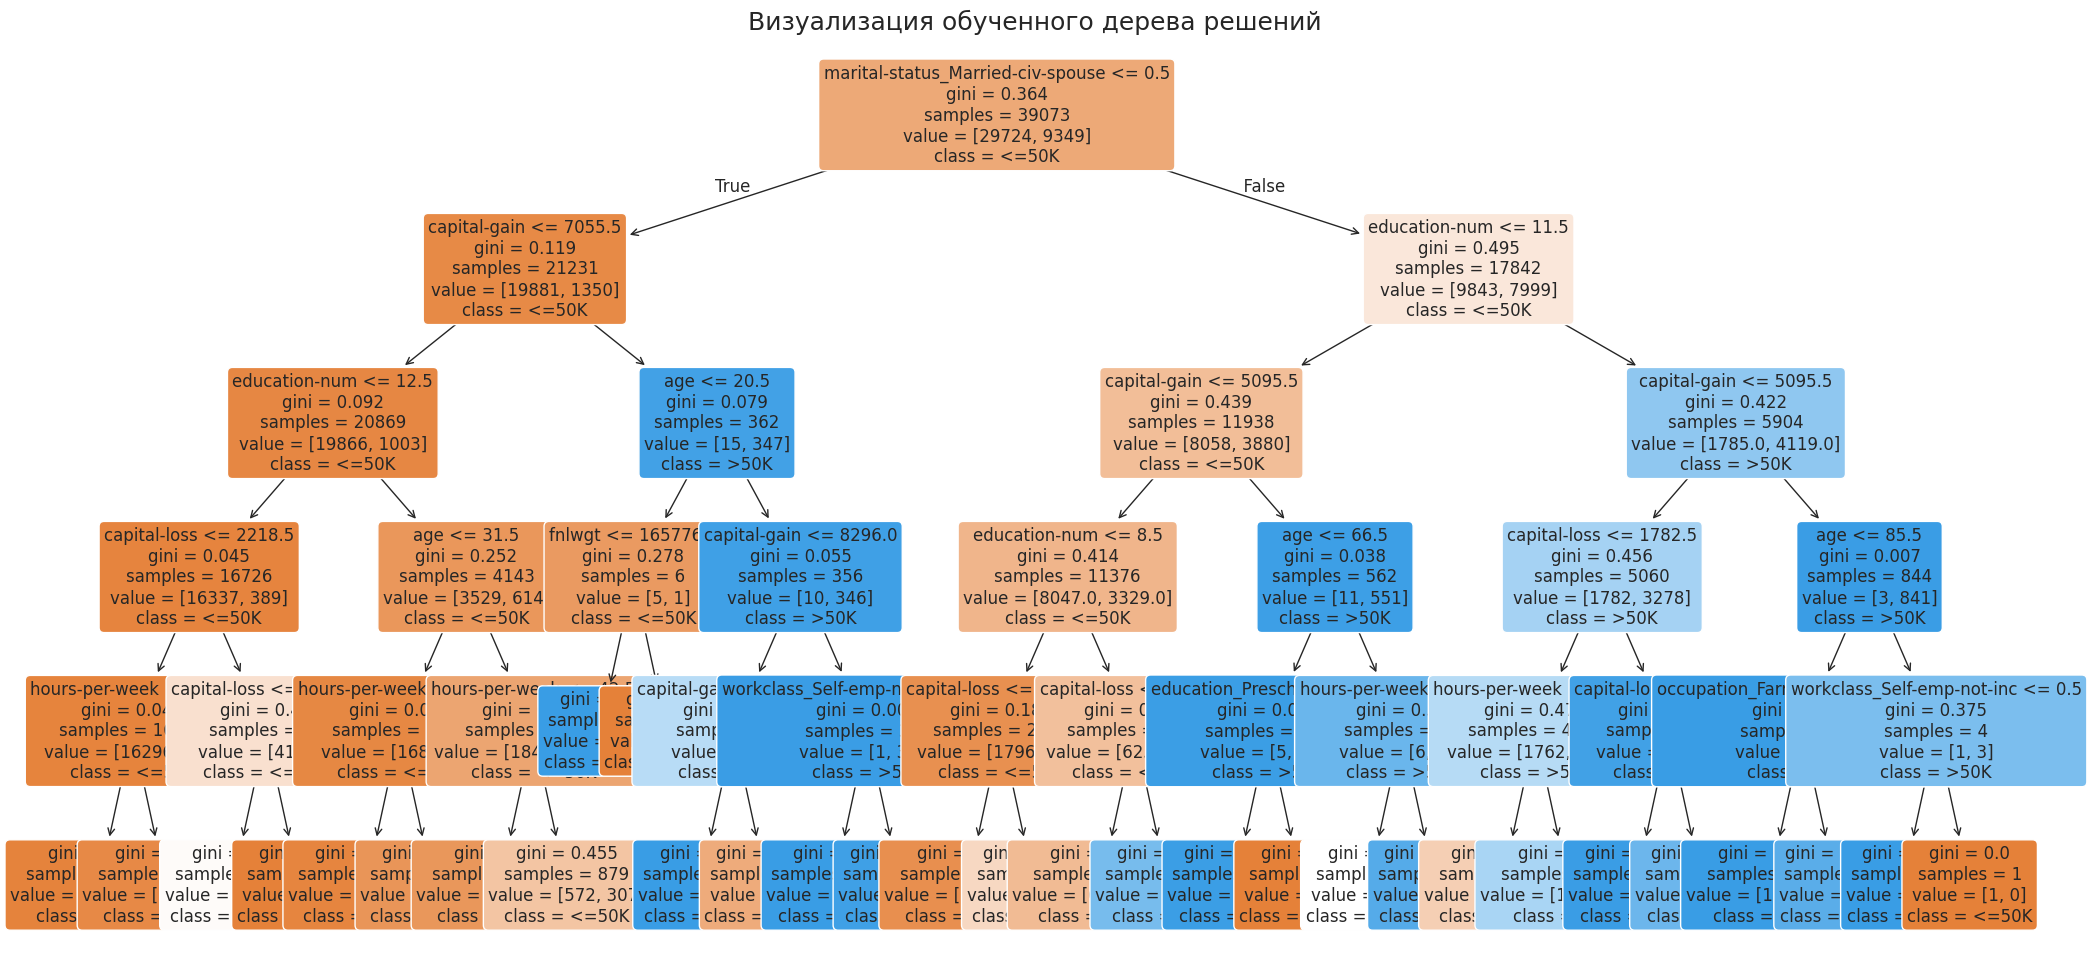

In [12]:
plt.figure(figsize=(25, 12))
plot_tree(
    tree_model,
    feature_names=X.columns.tolist(),
    class_names=['<=50K', '>50K'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('Визуализация обученного дерева решений', fontsize=18)
plt.show()

### Заключение
В ходе лабораторной работы был решен бизнес-кейс по классификации доходов граждан. 
Была проведена полная предобработка данных: обработаны пропуски, категориальные признаки переведены в числовой формат с помощью One-Hot Encoding, данные отмасштабированы. 
Были обучены три алгоритма машинного обучения. Сравнительный анализ с помощью метрик Accuracy и F1-score показал, что все три модели справились с задачей на приемлемом уровне. Визуализация дерева решений и анализ важности признаков показали, что ключевыми факторами, определяющими высокий доход в данном датасете, являются семейный статус и уровень образования. Цель лабораторной работы успешно достигнута.